In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
from matplotlib import _cm
import matplotlib.pyplot as plt

In [23]:
file = '../corpus/preprocess/extracted_notices.json'
df = pd.read_json(file)
df

,work_name,manuscript,full_notice_text,material,date,format,subject,keywords
0,Heroica,16. C. xxiii. ff. 2-69 b,**Royal 16. C. xxiii. ff. 2–69 b.**\n\nVellum;...,vellum,15th century,quarto (4to),A Greek dialogue by Flavius Philostratus discu...,"[Greek literature, Trojan War, dialogue, heroi..."
1,Iliaca,16. C. iv. A. B.,"## Royal 16. C. iv. A. B.\n\nPaper; two vols.,...",paper,1560-1565,quarto,A Greek poem titled 'Iliaca' by Joannes Tzetze...,"[Byzantine literature, Trojan War, Joannes Tze..."
2,Iliaca,16. D. iii. A. B.,## Royal 16. D. iii. A. B.\n\nPaper; xvth cent...,paper,15th century,folio,A Greek poem titled 'Iliaca' by Joannes Tzetze...,"[Greek poetry, medieval manuscript, Trojan War..."
3,Iliaca,Harley 5662. ff. 1-56,## Harley 5662. ff. 1–56.\n\nPaper; xvth cent....,paper,15th century,quarto,A Byzantine Greek epic poem titled 'Iliaca' by...,"[Byzantine literature, Greek epic, Johannes Tz..."
4,Dictys Cretensis,Burney 170,## Burney 170.\n\nVellum; late xvth cent. Quar...,vellum,late 15th century,quarto,"A Latin account of the Trojan War, attributed ...","[Trojan War, Dictys Cretensis, Latin manuscrip..."
...,...,...,...,...,...,...,...,...
503,Richard Coeur-de-Lion,Add. 31042 ff 125-163 b,"## Additional 31,042. ff. 125–163 b.\n\nPaper;...",paper,circa 1450,quarto,A metrical romance about King Richard I of Eng...,"[metrical romance, Richard the Lionheart, crus..."
504,Richard Cœur-de-Lion,Harley 4690. ff. 106-115,**Harley 4690.** ff. 106–115.\n\nVellum; xvth ...,vellum,15th century,folio,Abridged English metrical romance of Richard t...,"[metrical romance, Richard the Lionheart, abri..."
505,Turpin's Chronicle,Nero A. xi. ff. 8-63,### Nero A. xi. ff. 8–63.\n\nTurpin’s Chronicl...,vellum,12th century,folio,"A medieval chronicle attributed to Turpin, Arc...","[medieval chronicle, Charlemagne legend, Turpi..."
506,"Tinctoris, Compostella","Add. 12,213. ff. 160 b-181 b","**Additional 12,213.** ff. 160 b–181 b.\n\n**I...",vellum,12th century (c. 1140–1150),folio,A medieval guidebook detailing a pilgrimage ro...,"[pilgrimage, medieval travel, Santiago de Comp..."


In [ ]:
#  it possible to identify automatically any thematic cluster?  based on which criteria and for what purpose ?

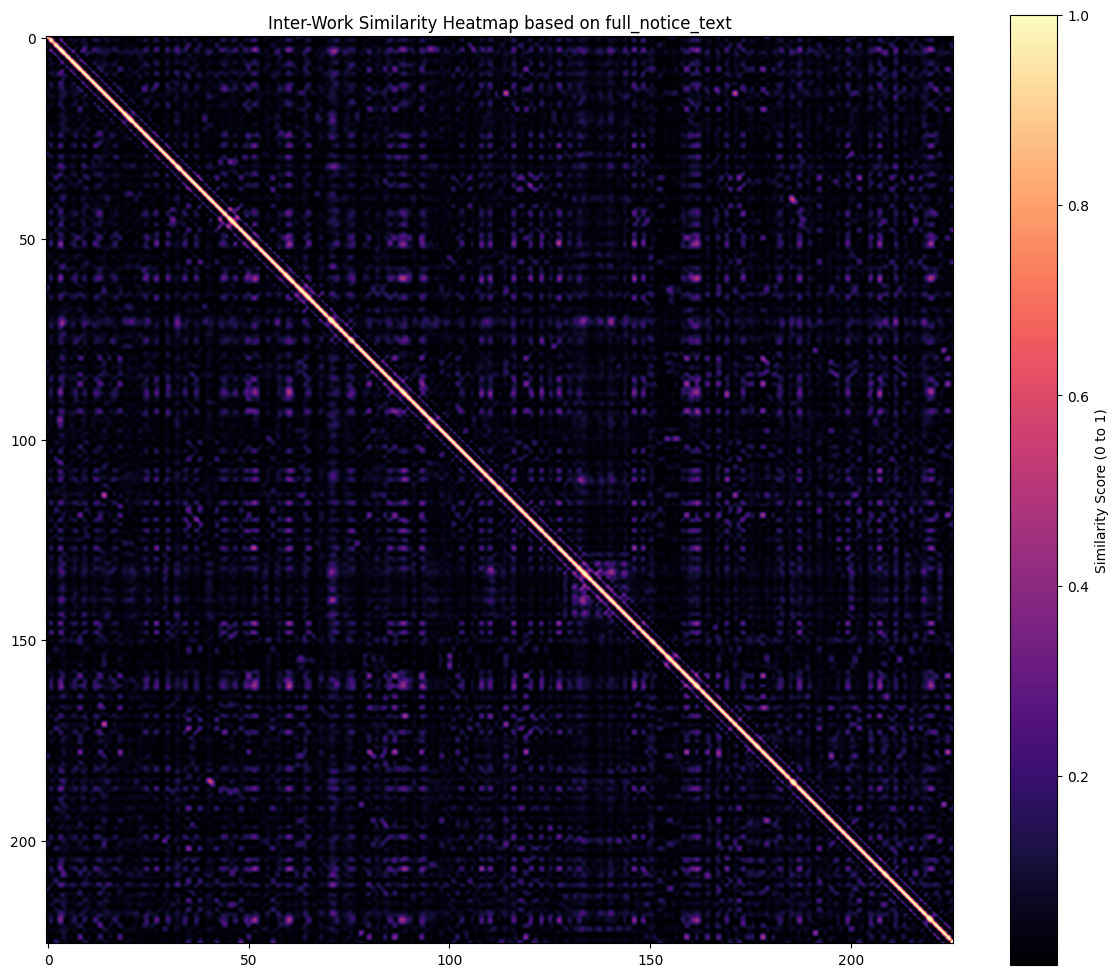

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# On adapte le code fait pour le code de philologie computationnelle https://github.com/Bizais-Lillig/robust_rythm/blob/main/Chrestien.ipynb
# le répertoire est peut-être encore en privé

def plot_work_similarity_heatmap(df, text_column='keywords'):
    grouped = df.groupby('work_name')[text_column].apply(lambda x: ' '.join(x.astype(str))).reset_index()
    
    #work_names = grouped['work_name'].tolist()
    corpus = grouped[text_column].tolist()

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(corpus)

    sim_matrix = cosine_similarity(tfidf_matrix)

    plt.figure(figsize=(12, 10))
    
    im = plt.imshow(sim_matrix, cmap='magma', interpolation='sinc', aspect='equal')
    
    plt.colorbar(im, label='Similarity Score (0 to 1)')
    #plt.xticks(range(len(work_names)), work_names, rotation=90)
    #plt.yticks(range(len(work_names)), work_names)
    
    plt.title(f'Inter-Work Similarity Heatmap based on {text_column}')
    plt.tight_layout()
    plt.show()

plot_work_similarity_heatmap(df)

In [25]:
import re

collections = ['Royal', 'Cotton', 'Harley', 'Lansdowne', 'Arundel', 
               'Burney', 'Sloane', 'Additional', 'Egerton']
def get_collection(text):
    text = str(text)
    for col in collections:
        if re.search(rf'\b{col}\b', text, re.IGNORECASE):
            return col
    return "Other"

df['collection'] = df['full_notice_text'].apply(get_collection)

grouped = df.groupby(['collection', 'work_name'])['full_notice_text'].apply(lambda x: ' '.join(x.astype(str))).reset_index()
grouped = grouped.sort_values('collection')

In [26]:
grouped

,collection,work_name,full_notice_text
0,Additional,A Propecye,"## Additional 27,879. Percy Folio, f. 239 b.\n..."
72,Additional,Scottish Ballads,"## Additional 22,311-12.\n\nPaper; before 1802..."
71,Additional,Samsons saga Fagra,## Additional 4863. ff. 47–68 b.\n\nPaper; xvi...
70,Additional,Saint Graal,## 19. C. vii.\n\nVellum; xivth cent. Folio; f...
69,Additional,Saga of Ajax Frækni,## Additional 4884. ff. 167–178.\n\nPaper; xvi...
...,...,...,...
307,Sloane,Cassandra,## Sloane 457.\n\nPaper; xvirth cent. Duodecim...
305,Sloane,Alexander the Great,## Sloane 1619. ff. 3–17 b.\n\nVellum; early x...
315,Sloane,Tale of Gamelyn,## Sloane 1686. ff. 71–86 b.\n\nPaper; xvth ce...
309,Sloane,Guy of Warwick,## Sloane 1044. f. 625.\n\nVellum; xvth cent. ...


c:\Users\mathi\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\mathi\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


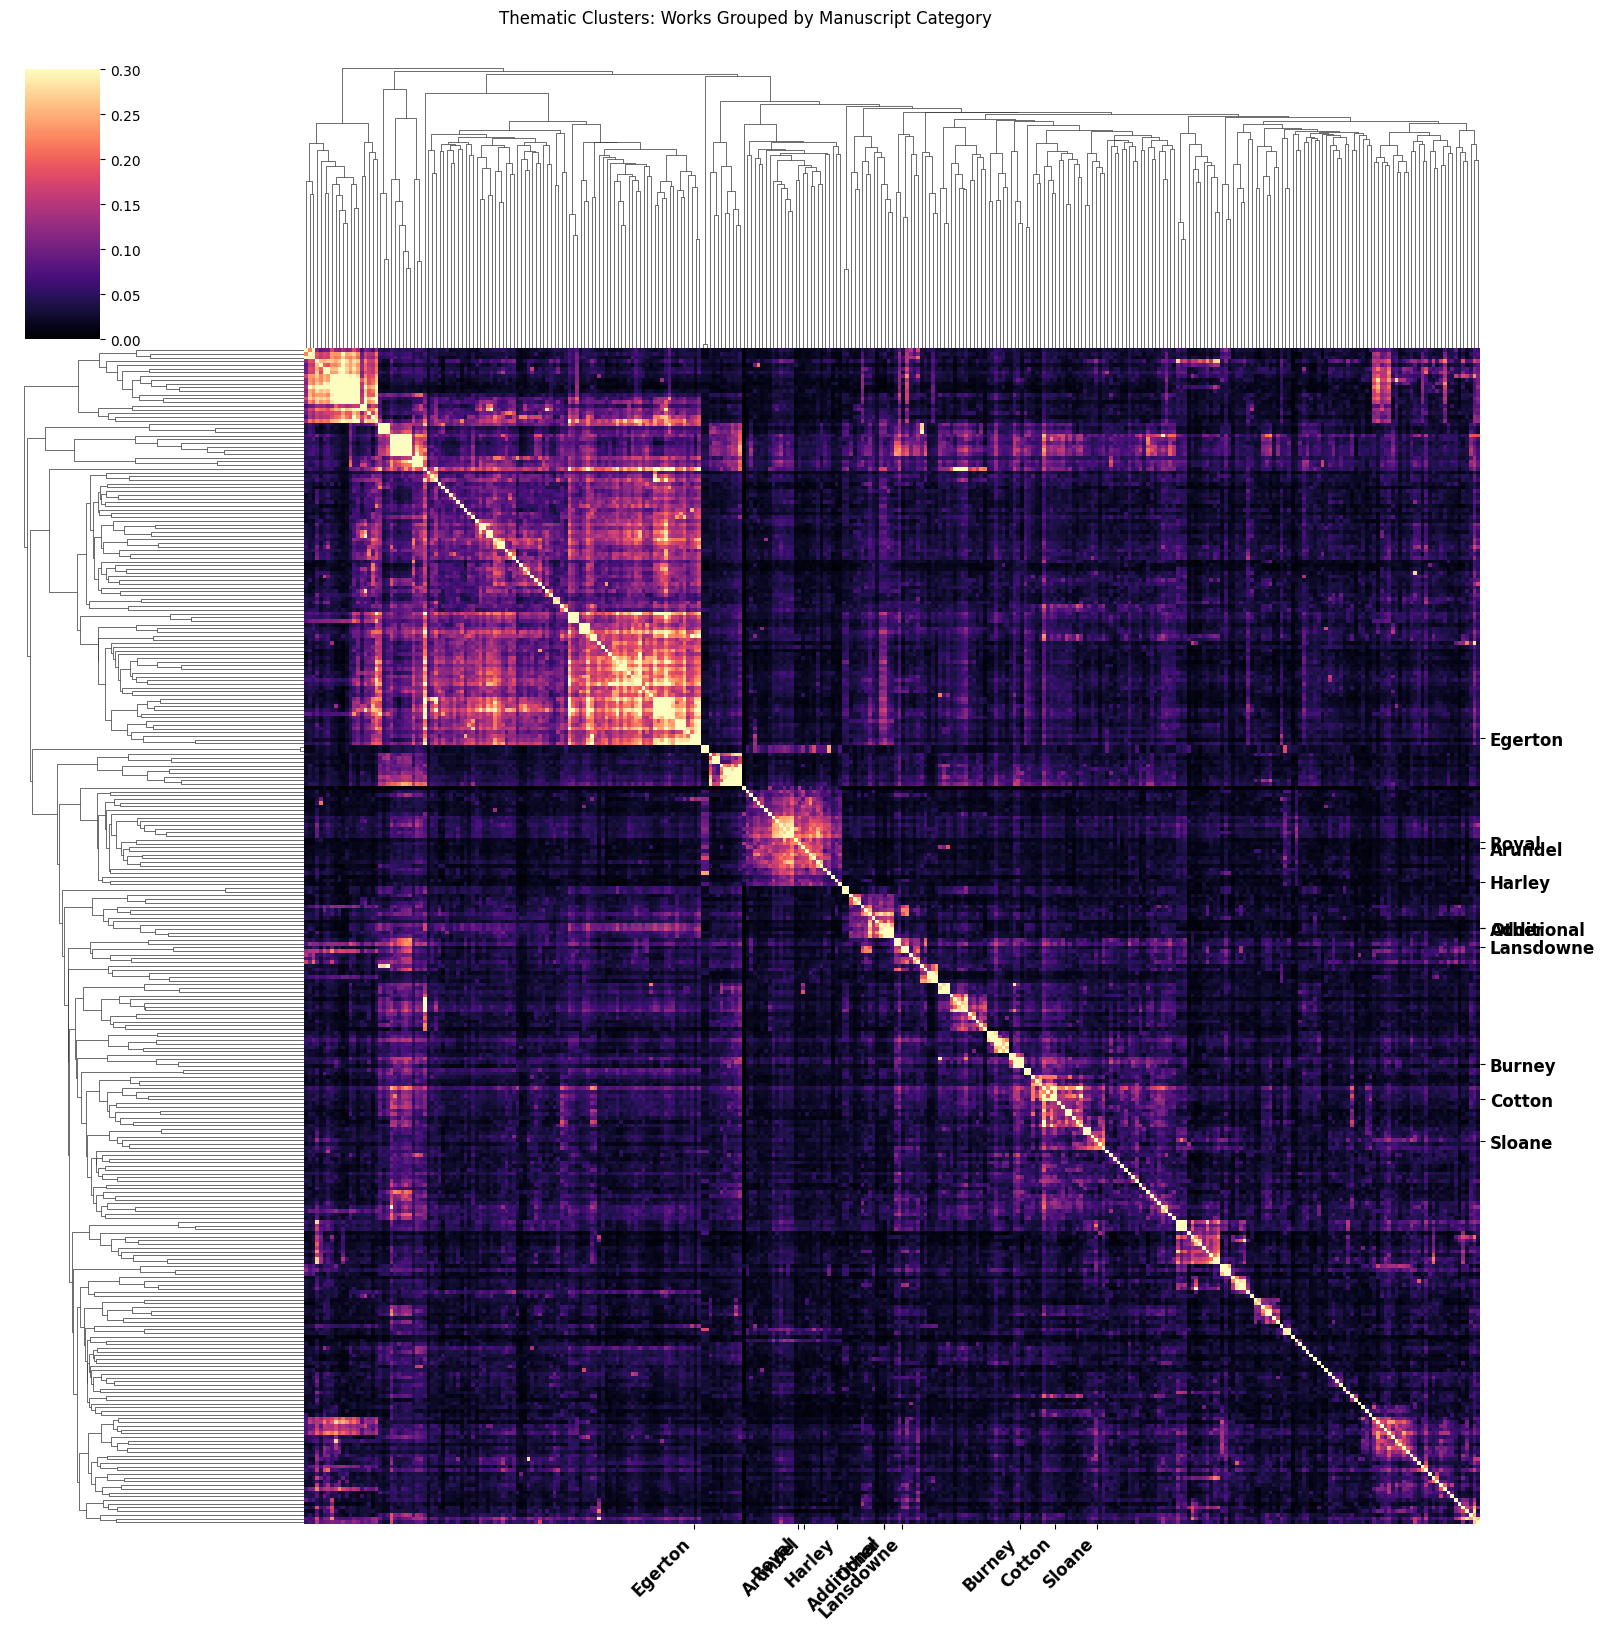

In [45]:
def plot_collection_heatmap_clean_labels(grouped_df):

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(grouped_df['full_notice_text'])
    sim_matrix = cosine_similarity(tfidf_matrix)

    g = sns.clustermap(sim_matrix, 
                       xticklabels=False, # CACHER LABELS POUR QUE CE SOIT PLUS CLAIR
                       yticklabels=False, 
                       cmap='magma', 
                       figsize=(15, 15),
                       vmin=0, 
                       vmax=0.3)

    reordered_indices = g.dendrogram_row.reordered_ind
    reordered_categories = grouped_df.iloc[reordered_indices]['collection'].values
    
    cat_positions = {}
    for i, cat in enumerate(reordered_categories):
        if cat not in cat_positions:
            cat_positions[cat] = []
        cat_positions[cat].append(i)
    
    label_ticks = []
    label_names = []
    for cat, indices in cat_positions.items():
        label_ticks.append(np.mean(indices))
        label_names.append(cat)

    g.ax_heatmap.set_xticks(label_ticks)
    g.ax_heatmap.set_xticklabels(label_names, rotation=45, ha='right', fontsize=12, fontweight='bold')
    
    g.ax_heatmap.set_yticks(label_ticks)
    g.ax_heatmap.set_yticklabels(label_names, rotation=0, fontsize=12, fontweight='bold')

    plt.suptitle('Thematic Clusters: Works Grouped by Manuscript Category', y=1.02)
    plt.show()

plot_collection_heatmap_clean_labels(grouped)

--- Metrics for Threshold: 0.05 ---
Nodes: 317 | Edges: 14705
Density: 0.2936
Average Degree: 92.78
Average Clustering Coefficient: 0.6625

--- Metrics for Threshold: 0.1 ---
Nodes: 317 | Edges: 4560
Density: 0.0910
Average Degree: 28.77
Average Clustering Coefficient: 0.6316

--- Metrics for Threshold: 0.15 ---
Nodes: 317 | Edges: 1958
Density: 0.0391
Average Degree: 12.35
Average Clustering Coefficient: 0.5730

--- Metrics for Threshold: 0.25 ---
Nodes: 317 | Edges: 412
Density: 0.0082
Average Degree: 2.60
Average Clustering Coefficient: 0.2765



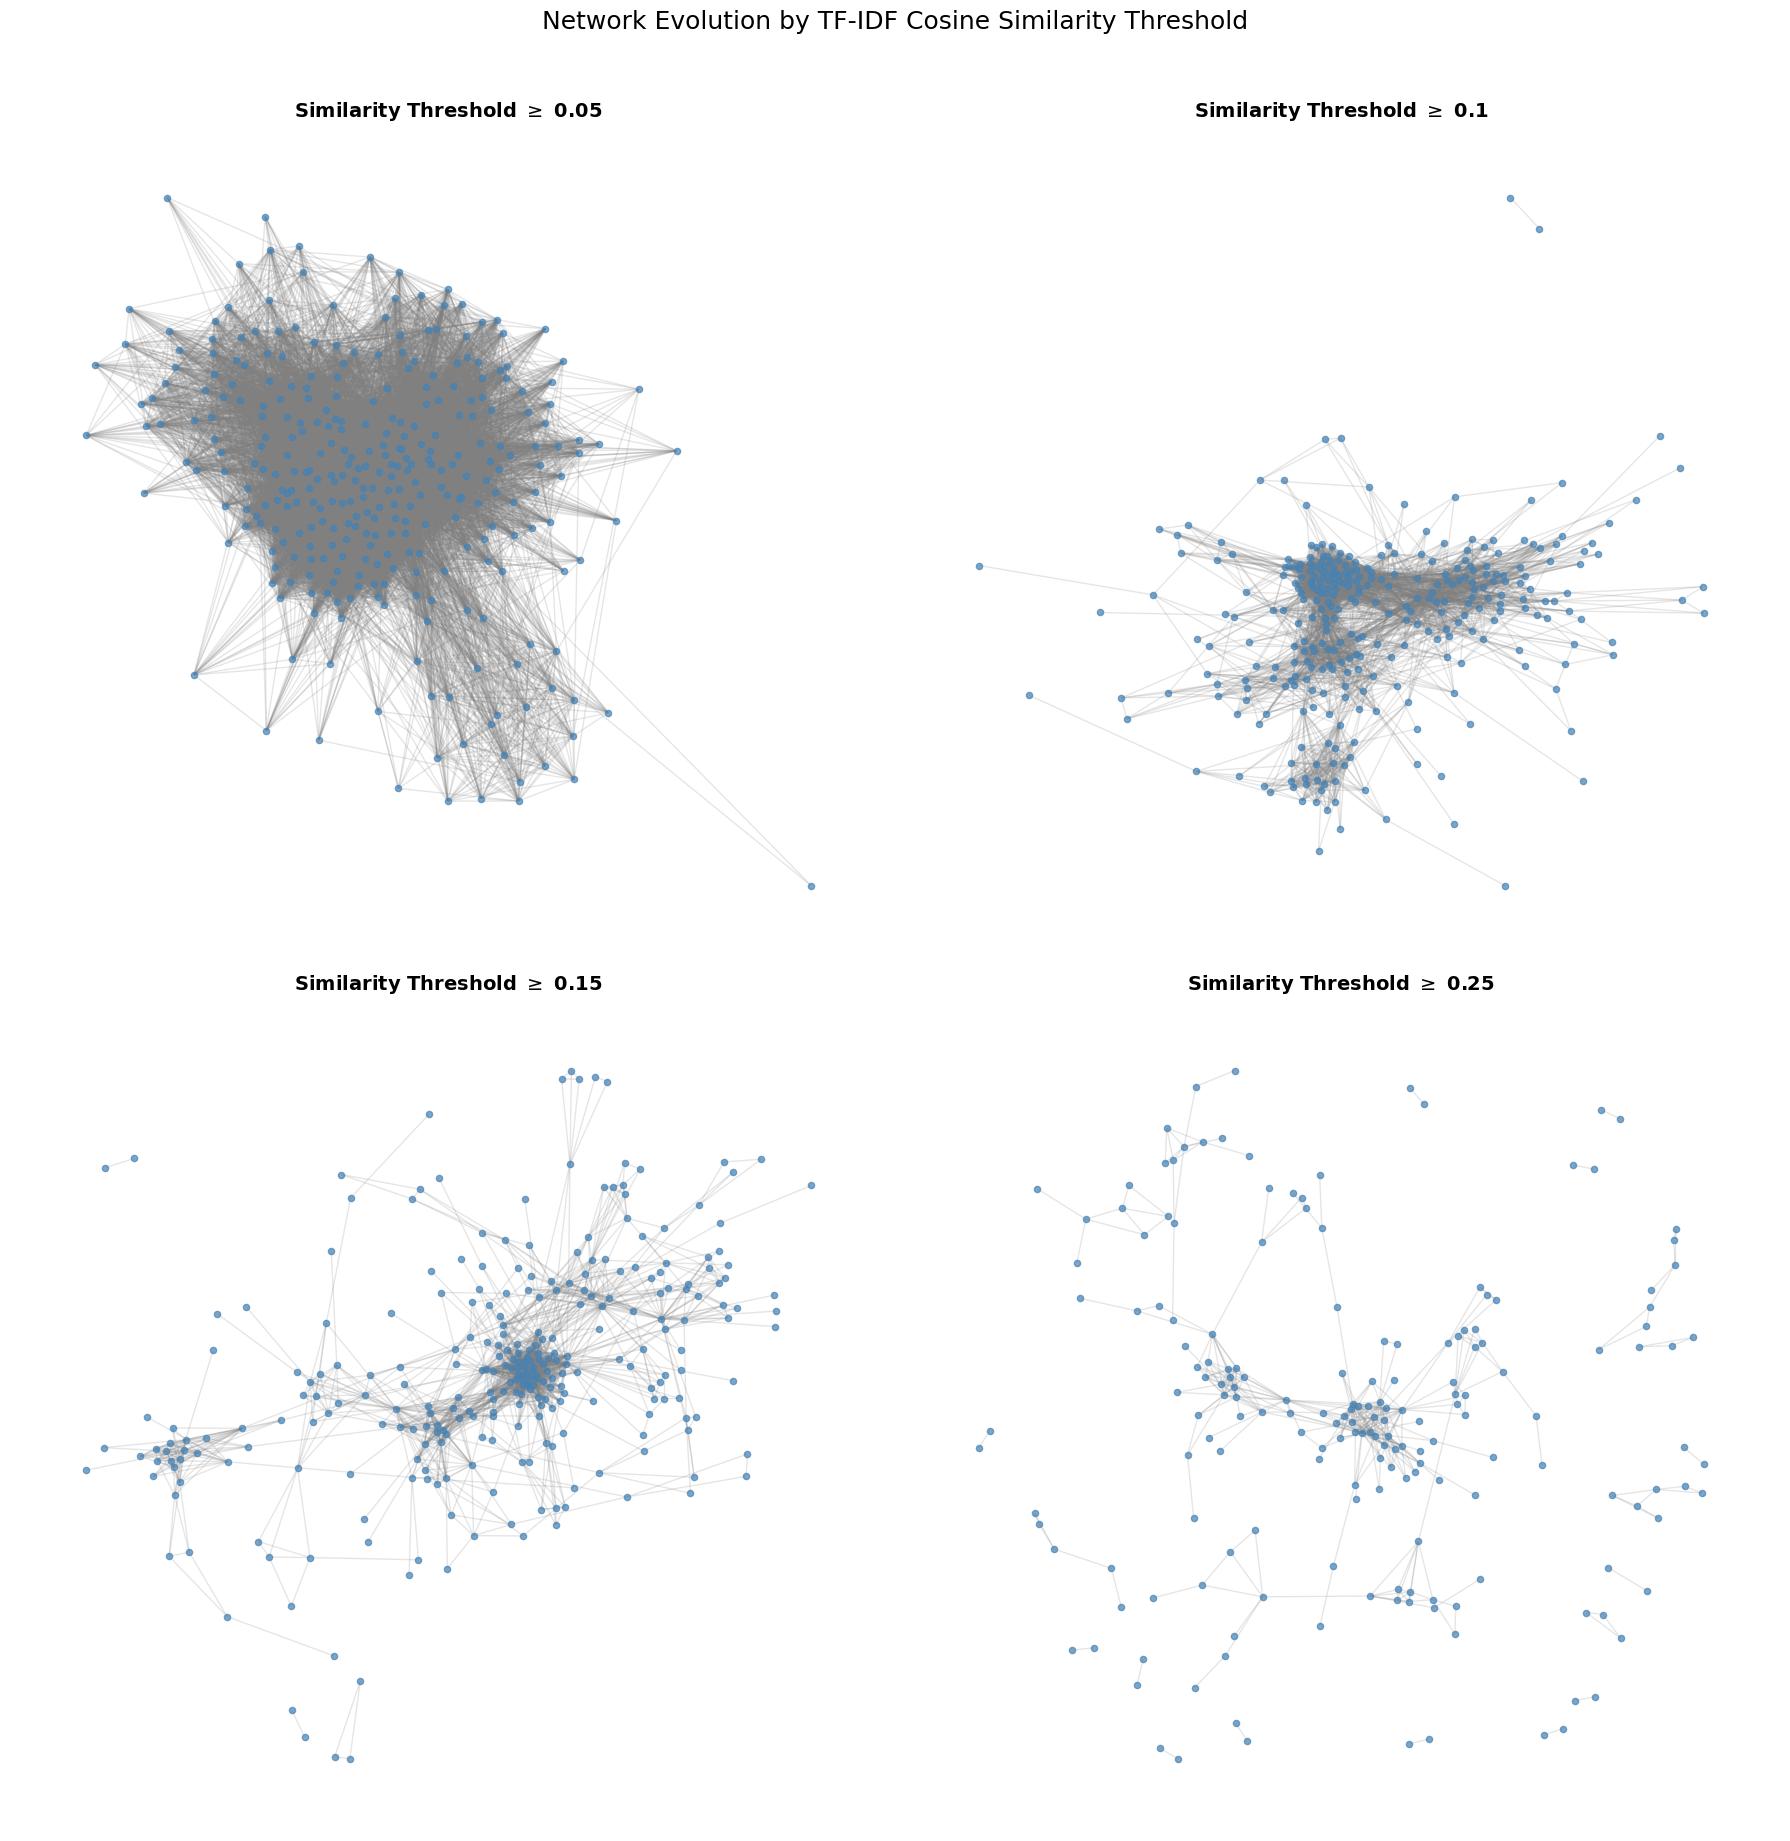

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def plot_network_evolution_and_metrics(grouped_df):

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(grouped_df['full_notice_text'])
    sim_matrix = cosine_similarity(tfidf_matrix)
    
    thresholds = [0.05, 0.10, 0.15, 0.25]
    collections = grouped_df['collection'].values

    fig, axes = plt.subplots(2, 2, figsize=(18, 18))
    axes = axes.flatten()
    
    for idx, threshold in enumerate(thresholds):

        G = nx.Graph()
        
        for i in range(len(collections)):
            G.add_node(i, collection=collections[i])
            
        # Using np.triu_indices to only iterate over the upper triangle (ignoring self-loops)
        # je connaissais pas du tout triu_indices!
        rows, cols = np.triu_indices(sim_matrix.shape[0], k=1)
        valid_edges = sim_matrix[rows, cols] >= threshold
        
        edges_to_add = zip(rows[valid_edges], cols[valid_edges])
        G.add_edges_from(edges_to_add)
        
        density = nx.density(G)
        
        if G.number_of_edges() > 0:
            avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

            # approximation or sample for clustering if the graph is too large
            if G.number_of_nodes() > 1000:
                avg_clustering = nx.average_clustering(G, trials=100) 
            else:
                avg_clustering = nx.average_clustering(G)
        else:
            avg_degree = 0
            avg_clustering = 0
            
        print(f"--- Metrics for Threshold: {threshold} ---")
        print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
        print(f"Density: {density:.4f}")
        print(f"Average Degree: {avg_degree:.2f}")
        print(f"Average Clustering Coefficient: {avg_clustering:.4f}\n")
        
        ax = axes[idx]
        
        # Remove isolated nodes for a cleaner visualization (optional, but recommended)
        G_plot = G.copy()
        G_plot.remove_nodes_from(list(nx.isolates(G_plot)))
        
        pos = nx.spring_layout(G_plot, k=0.15, seed=42)

        nx.draw_networkx_nodes(G_plot, pos, ax=ax, node_size=20, alpha=0.7, node_color='steelblue')
        nx.draw_networkx_edges(G_plot, pos, ax=ax, alpha=0.2, edge_color='gray')
        
        ax.set_title(f'Similarity Threshold $\geq$ {threshold}', fontsize=14, fontweight='bold')
        ax.axis('off')

    plt.suptitle('Network Evolution by TF-IDF Cosine Similarity Threshold', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

plot_network_evolution_and_metrics(grouped)

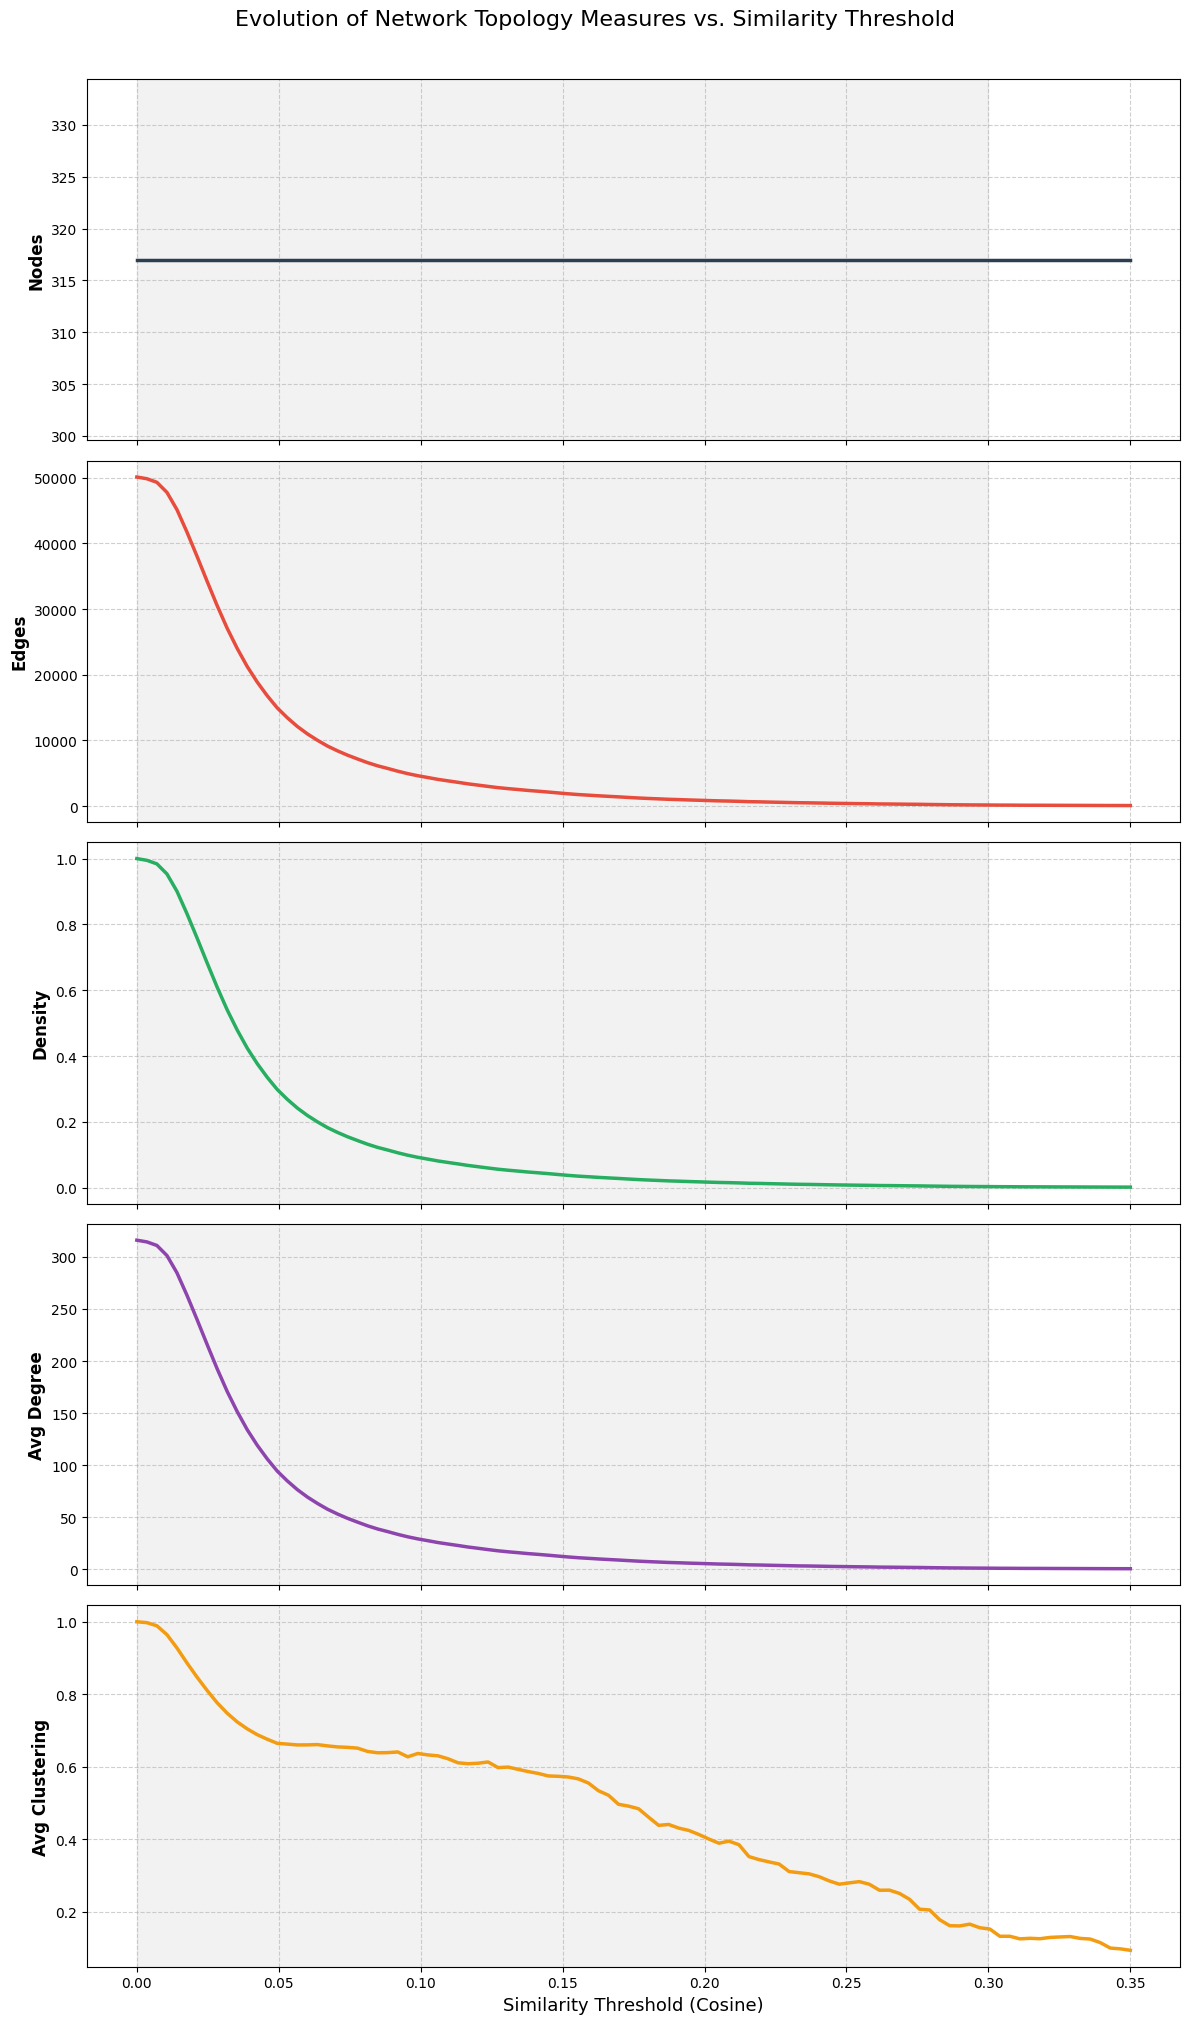

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def plot_metric_evolution(grouped_df):

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(grouped_df['full_notice_text'])
    sim_matrix = cosine_similarity(tfidf_matrix)
    
    thresholds = np.linspace(0.0, 0.35, 100)
    results = {
        'Nodes': [],
        'Edges': [],
        'Density': [],
        'Avg Degree': [],
        'Avg Clustering': []
    }
    
    rows, cols = np.triu_indices(sim_matrix.shape[0], k=1)
    
    for t in thresholds:
        G = nx.Graph()
        G.add_nodes_from(range(sim_matrix.shape[0]))
        
        valid_mask = sim_matrix[rows, cols] >= t
        edges = zip(rows[valid_mask], cols[valid_mask])
        G.add_edges_from(edges)
        
        num_nodes = G.number_of_nodes()
        num_edges = G.number_of_edges()
        density = nx.density(G)
        avg_deg = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0
        
        if num_nodes > 500:
            clustering = nx.average_clustering(G, trials=50) 
        else:
            clustering = nx.average_clustering(G)
            
        results['Nodes'].append(num_nodes)
        results['Edges'].append(num_edges)
        results['Density'].append(density)
        results['Avg Degree'].append(avg_deg)
        results['Avg Clustering'].append(clustering)

    # Visualization
    fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=True)
    metrics = list(results.keys())
    colors = ['#2c3e50', '#e74c3c', '#27ae60', '#8e44ad', '#f39c12']

    for i, metric in enumerate(metrics):
        axes[i].plot(thresholds, results[metric], color=colors[i], lw=2.5)
        axes[i].set_ylabel(metric, fontweight='bold', fontsize=12)
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
        axes[i].axvspan(0, 0.3, color='gray', alpha=0.1)

    axes[-1].set_xlabel('Similarity Threshold (Cosine)', fontsize=13)
    plt.suptitle('Evolution of Network Topology Measures vs. Similarity Threshold', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

plot_metric_evolution(grouped)